In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
from sklearn.neighbors import KNeighborsRegressor

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv("Salary_Data.csv")

In [11]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [12]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(6704, 6)


In [13]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')


In [14]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
None


In [15]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [16]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [17]:
df = df.dropna()

In [18]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [19]:
le = LabelEncoder()

In [20]:
df["Gender"] = le.fit_transform(df["Gender"])

In [21]:
df["Education Level"] = le.fit_transform(df["Education Level"])

In [22]:
df["Job Title"] = le.fit_transform(df["Job Title"])

In [23]:
X = df.drop("Salary", axis=1)

In [24]:
y = df["Salary"]

print("\nFeature Columns:")
print(X.columns)


Feature Columns:
Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (5358, 5)
Testing Data Shape: (1340, 5)


In [27]:
scaler = StandardScaler()

In [28]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [29]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)

print("\nKNN Model Trained Successfully!")



KNN Model Trained Successfully!


In [30]:
y_pred = model.predict(X_test)

print("\nPredictions Completed!")


Predictions Completed!


In [31]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

print("\nActual vs Predicted Salaries:")
display(comparison.head(10))


Actual vs Predicted Salaries:


,Actual Salary,Predicted Salary
0,150000.0,150000.0
1,75969.0,104715.4
2,100000.0,100000.0
3,60000.0,61000.0
4,80000.0,80000.0
5,190000.0,193000.0
6,72000.0,72000.0
7,55000.0,55000.0
8,195000.0,198000.0
9,130000.0,132000.0


In [32]:
mse = mean_squared_error(y_test, y_pred)

In [33]:
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL EVALUATION")
print("==============================")

print("Mean Squared Error:", mse)

print("R2 Score:", r2)


MODEL EVALUATION
Mean Squared Error: 130885484.25814924
R2 Score: 0.9540987708926839


In [34]:
k_values = range(1, 21)

errors = []

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, pred)

    errors.append(mse)

print("\nErrors for Different K Values:")
print(errors)


Errors for Different K Values:
[120593031.78059702, 101161925.06753731, 110450470.9942786, 118956954.2068097, 130885484.25814924, 138214260.85186568, 149613846.09148642, 162643958.77955922, 173412492.4099226, 180005966.8421194, 187976679.13128778, 196956219.0557525, 203487370.94442287, 209329364.12762332, 211106772.61911112, 215807224.42439365, 221484588.0120746, 227381441.5209554, 231637314.46330056, 237483716.769291]


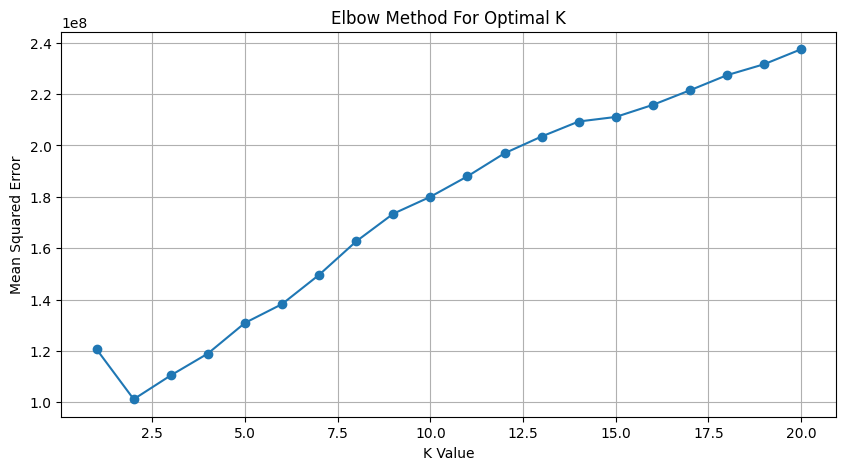

In [35]:
plt.figure(figsize=(10,5))

plt.plot(k_values, errors, marker='o')

plt.xlabel("K Value")

plt.ylabel("Mean Squared Error")

plt.title("Elbow Method For Optimal K")

plt.grid(True)

plt.show()

In [36]:
print("\nFeature Order:")
print(X.columns)


Feature Order:
Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')


In [37]:
sample = [[30, 1, 0, 5, 2]]

In [38]:
sample_scaled = scaler.transform(sample)


prediction = model.predict(sample_scaled)

print("\n==============================")
print("CUSTOM PREDICTION")
print("==============================")

print("Predicted Salary:", prediction[0])


CUSTOM PREDICTION
Predicted Salary: 96000.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


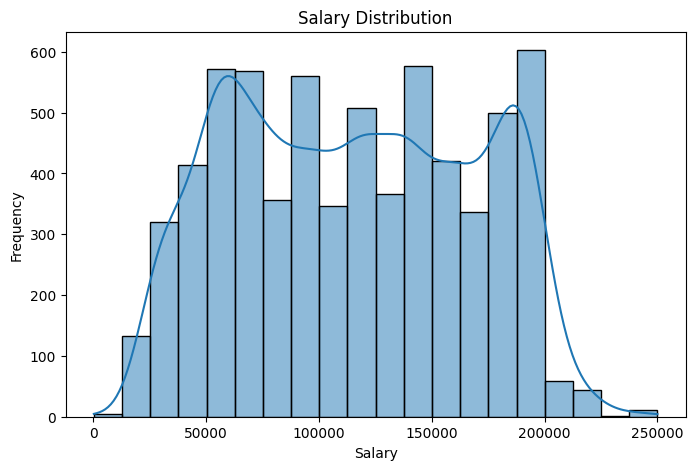

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], bins=20, kde=True)

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.show()

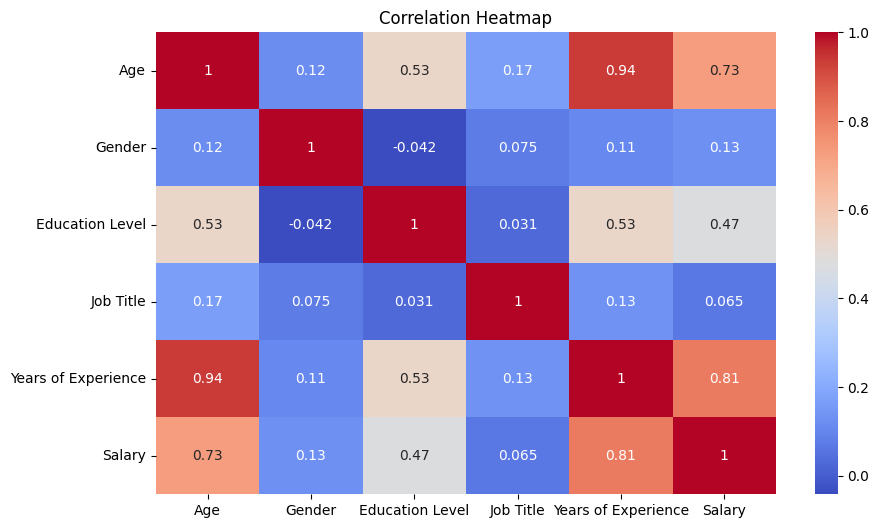

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [41]:
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")

🎉 PROJECT COMPLETED SUCCESSFULLY!
